Notes

Course
https://molssi.org/learn-quantum-chemistry-simulation-with-molssis-new-credentialed-online-course/

Tutorials
https://education.molssi.org/resources.html#molecular-modeling

https://github.com/DocMinus/psi4_rdkit

In [1]:
### Use PSI4
# from https://education.molssi.org/qm-tools/aio.html

import psi4


In [1]:
# import the python modules that we will use
import psi4
import numpy as np
#%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
# function to find the bond distance for two specific atoms in the optimization file
def plot_R(filename, a, b):
    """
    Function to measure the distance between two atoms in a psi4 geometry optimization output file

    Usage: plot_R(filename, a, b)

    Inputs:
    filename: name of psi4 output file from geometry optimization calclaultion
    a and b: atom numbers for two atoms you want to measure the distance between

    Output: list of bond distance at for each optimization step
    """    
# OLD CODE: NEEDED EDITING. HAD MANY ERRORS. HAS THE OUTPUT FILE FORMAT CHANGED?
#    with open(filename) as f:
#        pair_notation = 'R(' + str(a) + ',' + str(b) + ')'
#        print(pair_notation)
#        rows_with_R_pairs = [line.split() for line in f if line.find(pair_notation) > 1 and
#                             line.strip().split()[1].startswith(pair_notation)]
#        print(rows_with_R_pairs)
#        bond_distances = []
#        bond_distances.append(float(rows_with_R_pairs[0][3]))
#        for item in rows_with_R_pairs:
#            bond_distances.append(float(item[6]))
#        return bond_distances
    

    with open(filename) as f:
        pair_notation = 'R(' + str(a) + ',' + str(b) + ')'
        rows_with_R_pairs = [line.split() for line in f if line.find(pair_notation) > 0 and
                             line.strip().split()[0].startswith(pair_notation) and
                             line.strip().split()[1] == '=']
        
        bond_distances = []
        for item in rows_with_R_pairs:
#            print(item)
            bond_distances.append(float(item[3]))
        return bond_distances


# function to find the energy in the optimization file
def plot_energy(filename):
    """
    Function to find the energy in a psi4 optimization file.

    Usage: plot_energy(filename)

    Inputs: name of psi4 output file from geometry optimization calclaultion
    filename: name

    Output: list of energy values from each optimization step
    """

    with open(filename) as f:
        energy_string = 'Final Energy'
#        energy_values = [ float(line.split()[3]) for line in f if line.strip().startswith(energy_string) ]
        energy_values = [ float(line.split()[3]) for line in f if energy_string in line.strip()]
        return energy_values
    



In [5]:
# set the amount of memory that you will need
psi4.set_memory('2 GB')

# set the number of threads (processes) for Psi4 to use
# (~all modern computers can handle 2 threads)
psi4.set_num_threads(2)

# set the molecule name for your files and plots
molecule_name = "benzene"

# enter the charge, multiplicity, and starting coordinates of the atoms in your molecule
benzene = psi4.geometry("""
0 1
   C       -3.98116        3.81771        0.00000
   C       -2.63351        3.75967        0.10838
   C       -2.11978        2.80187       -0.29323
   C       -2.68901        1.83558       -0.80805
   C       -3.92704        1.83138       -0.93484
   C       -4.58021        2.71451       -0.58263
   H       -4.52562        4.63006        0.32966
   H       -2.09025        4.53029        0.52795
   H       -1.09209        2.75239       -0.21305
   H       -2.13621        1.02769       -1.13476
   H       -4.38300        1.01321       -1.36811
   H       -5.60487        2.68217       -0.70124
""")

# Set the name of the output file for the initial energy calculation
# Calculate the initial energy of the molecule using the Hartree-Fock method
# and the cc-pVDZ basis set and print the output to a file
psi4.set_output_file(F'{molecule_name}_energy_initial.dat', False)
psi4.energy('scf/cc-pVDZ')

# Set the name of the output file to write the geometry information
# Print atomic coordinates and interatomic distances to this file
psi4.set_output_file(F'{molecule_name}_geometry_initial.dat', False)
benzene.print_out_in_angstrom()
benzene.print_distances()

In [6]:
# psi4.set_module_options('scf', {'maxiter': 500})
# psi4.set_options({'geom_maxiter': 100})

# optimize the molecular geometry
psi4.set_output_file(F'{molecule_name}_geometry_optimization.dat', False)
psi4.optimize('scf/cc-pVDZ', molecule=benzene)

# print the optimized atomic coordinates and interatomic distances
psi4.set_output_file(F'{molecule_name}_geometry_final.dat', False)
benzene.print_out_in_angstrom()
benzene.print_distances()

Optimizer: Optimization complete!


In [7]:
plot_R('benzene_geometry_optimization.dat',1,2)

[1.353246,
 1.3869,
 1.387652,
 1.387151,
 1.387738,
 1.38795,
 1.388175,
 1.388323,
 1.388392]

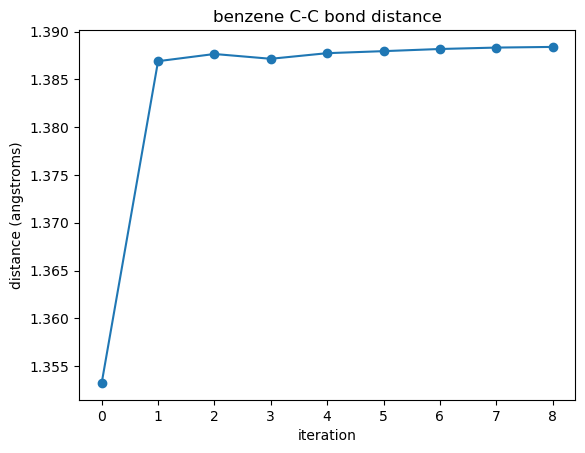

In [8]:
# find the bond distance for atoms C1 and C2
bond_distances = plot_R('benzene_geometry_optimization.dat',1,2)

# plot the bond distances at each iteration of geometry optimization
plt.plot(bond_distances,'o-')
plt.xlabel('iteration')
plt.ylabel('distance (angstroms)')
plt.title(molecule_name + ' C-C bond distance')
plt.show()

In [9]:
plot_energy('benzene_geometry_optimization.dat')

[-230.47781611773024,
 -230.6950542938673,
 -230.71763013180896,
 -230.72108252286387,
 -230.72173925789497,
 -230.72188283722775,
 -230.72192241239617,
 -230.72192541256942,
 -230.72192577420492]

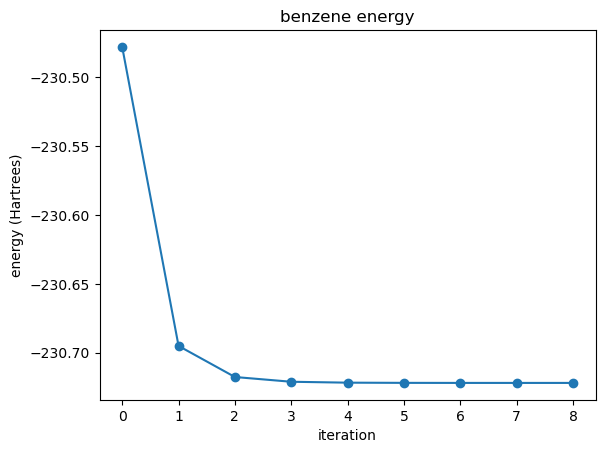

In [10]:
# find the energies from this optimization file
energy_values = plot_energy('benzene_geometry_optimization.dat')

# plot the energies at each iteration
plt.figure()
plt.plot(energy_values,'o-')
plt.xlabel("iteration")
plt.ylabel("energy (Hartrees)")
plt.title(F'{molecule_name} energy')

#plt.ylim(min(energy_values), energy_values[0])
plt.show()

## Visualize


In [11]:
# set the amount of memory that you will need
psi4.set_memory('2 GB')

# set the number of threads (processes) for Psi4 to use
# (~all modern computers can handle 2 threads)
psi4.set_num_threads(2)

# set the molecule name for your files and plots
molecule_name = "benzene"

# enter the charge, multiplicity, and starting coordinates of the atoms in your molecule
xyz = ("""
0 1
   C       -3.98116        3.81771        0.00000
   C       -2.63351        3.75967        0.10838
   C       -2.11978        2.80187       -0.29323
   C       -2.68901        1.83558       -0.80805
   C       -3.92704        1.83138       -0.93484
   C       -4.58021        2.71451       -0.58263
   H       -4.52562        4.63006        0.32966
   H       -2.09025        4.53029        0.52795
   H       -1.09209        2.75239       -0.21305
   H       -2.13621        1.02769       -1.13476
   H       -4.38300        1.01321       -1.36811
   H       -5.60487        2.68217       -0.70124
""")
                        
                        
psi4.set_output_file(F'{molecule_name}_trial_wfn.dat', False)

benzene = psi4.geometry(xyz)
benzene.update_geometry()
benzene.print_out()  # print the geometry to the output file with atomic masses

energy, wave_function = psi4.optimize(
  'hf/6-31g*',
   return_wfn =True,
  molecule=benzene
)

benzene.print_out_in_angstrom() # print the geometry to the output file in angstroms
benzene.print_distances() # print the interatomic distances to the output file

Optimizer: Optimization complete!


In [56]:
import py3Dmol

options={
        'backgroundColor': 'lightgray',
        # Global lighting
        'light': True,
        'ambient': 0.4,
        'diffuse': 0.6,
        'specular': 0.1,
        'shininess': 15,
    }




xyz_string = benzene.save_string_xyz_file()
print(xyz_string)

# 3. Visualize with py3Dmol
view = py3Dmol.view(width=400, height=400, options=options)
view.addModel(xyz_string, 'xyz')
view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
view.setBackgroundColor ('#f9f9f9')

view.zoomTo()
view.show()


12

 C   -0.725665779400    1.094104944476    0.444785861040
 C    0.653958297995    1.077941886639    0.576203946468
 C    1.379885491074   -0.016436602458    0.131324184477
 C    0.725844693086   -1.094026003476   -0.444710495110
 C   -0.654237972579   -1.077689492024   -0.576120216942
 C   -1.379776434577    0.016106941775   -0.131477627257
 H   -1.288936057873    1.942953373226    0.789818637506
 H    1.161594948975    1.914192542216    1.023234324087
 H    2.450540587260   -0.028935799731    0.233338938461
 H    1.288824303494   -1.943014068049   -0.789859403026
 H   -1.161683443381   -1.914045356979   -1.023204319705
 H   -2.450439112758    0.028829366187   -0.233395482774



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
q = benzene.save_string_xyz_file()
print(q)

In [45]:
dir(benzene)

['B787',
 'BFS',
 'Z',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '_initial_cartesian',
 '_pybind11_conduit_v1_',
 'activate_all_fragments',
 'add_atom',
 'atom_at_position',
 'basis_on_atom',
 'center_of_mass',
 'charge',
 'clone',
 'com_fixed',
 'comment',
 'connectivity',
 'create_psi4_string_from_molecule',
 'deactivate_all_fragments',
 'distance_matrix',
 'extract_subsets',
 'fZ',
 'fcharge',
 'find_highest_point_group',
 'find_point_group',
 'fix_com',
 'fix_orientation',
 'flabel',
 'fmass',
 'form_symmetry_information',
 'format_molecule_for_mol',
 'from_arrays',
 'from_dict',
 'from_schema',
 'from_string',
 'fsymbol',
 'ftrue_atomic_number',
 'full_geome

In [52]:
help(benzene.to_string)

print(benzene.to_string(dtype='xyz+'))

Help on method to_string in module psi4.driver.qcdb.molecule:

to_string(dtype, units=None, atom_format=None, ghost_format=None, width=17, prec=12) method of psi4.core.Molecule instance
    Format a string representation of QM molecule.

12
0 1 C6H6
C                    -0.725665779400     1.094104944476     0.444785861040
C                     0.653958297995     1.077941886639     0.576203946468
C                     1.379885491074    -0.016436602458     0.131324184477
C                     0.725844693086    -1.094026003476    -0.444710495110
C                    -0.654237972579    -1.077689492024    -0.576120216942
C                    -1.379776434577     0.016106941775    -0.131477627257
H                    -1.288936057873     1.942953373226     0.789818637506
H                     1.161594948975     1.914192542216     1.023234324087
H                     2.450540587260    -0.028935799731     0.233338938461
H                     1.288824303494    -1.943014068049    -0.789859403026


In [26]:

import py3Dmol

xyz = """3
water
O 0 0 0
H 0 1 0
H 1 0 0
"""

view = py3Dmol.view(width=400, height=400)
view.addModel(xyz, 'xyz')
view.setStyle({'stick': {}})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Water Dimer



In [13]:

# set the amount of memory that you will need
psi4.set_memory('500 MB')

# set the molecule name for your files and plots
molecule_name = "h2o-dimer"
psi4.set_output_file(F'{molecule_name}_distancePES.dat', True)


# Define water dimer
water_dimer = """
O1
H2 1 1.0
H3 1 1.0 2 104.52
x4 2 1.0 1 90.0 3 180.0
--
O5 2 **R** 4 90.0 1 180.0
H6 5 1.0 2 120.0 4 90.0
H7 5 1.0 2 120.0 4 -90.0
"""

In [16]:
rvals = [1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 3.0, 3.5]
energies = []

# make a directory names 'molecule_name' to store the output files
import os
if not os.path.exists(molecule_name):
    os.makedirs(molecule_name)



for r in rvals:
    # Build a new molecule at each separation
    mol = psi4.geometry(water_dimer.replace('**R**', str(r)))

    # Compute the interaction energy
    psi4.set_output_file(F'{molecule_name}/{molecule_name}_{r:.1f}_energy.dat', False)
    E = psi4.energy('scf/aug-cc-pVDZ', molecule=mol, bsse_type='cp')

    # Place in a reasonable unit, kcal/mole in this case
    E = E*627.509

    # Append the value to our list
    energies.append(E)

print("Finished computing the potential energy surface!")

Finished computing the potential energy surface!


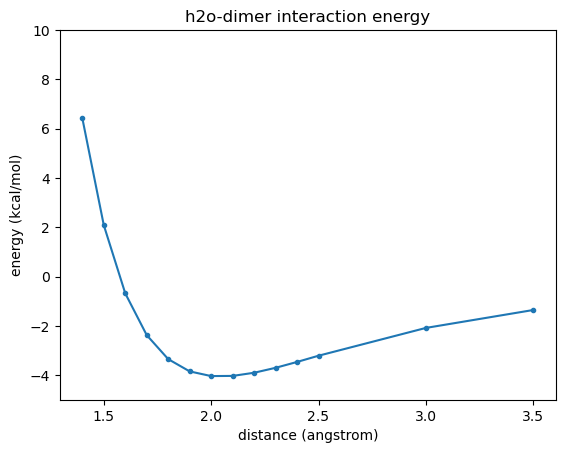

In [17]:
plt.plot(rvals,energies,".-");
plt.xlabel("distance (angstrom)")
plt.ylabel("energy (kcal/mol)")
plt.ylim(-5, 10)
plt.title(molecule_name + " interaction energy")

plt.show()

In [18]:
# set the molecule name for your files and plots
molecule_name = "h2o-dimer"

import os
if not os.path.exists(molecule_name):
    os.makedirs(molecule_name)

psi4.set_output_file(F'{molecule_name}/{molecule_name}_rotationPES.dat', True)

# Define water dimer
water_dimer2 = """
O1
H2 1 1.0
H3 1 1.0 2 104.52
x4 2 1.0 1 90.0 3 180.0
--
O5 2 **R** 4 90.0 1 180.0
H6 5 1.0 2 120.0 4 **A**
H7 5 1.0 2 120.0 4 **B**
"""

In [19]:
R = 1.8
Avals = np.linspace(start=-180,stop=180, num=25)

energies_R = []

for A in Avals:

    print(F'Computing dimer at {R:.1f} angstroms and {A:.2f} degrees')

    # Build a new molecule at each separation
    B = A-180
    molR = water_dimer2.replace('**R**', str(R))
    molA = molR.replace('**A**', str(A))
    molB = molA.replace('**B**', str(B))
    mol = psi4.geometry(molB)

    # calculate energy
    psi4.set_output_file(F'{molecule_name}/{molecule_name}_{R:.1f}_{A:.2f}_energy.dat', False)
    E = psi4.energy('scf/aug-cc-pVDZ', molecule=mol, bsse_type='cp')       
    E = E*627.509
    energies_R.append(E)

Computing dimer at 1.8 angstroms and -180.00 degrees
Computing dimer at 1.8 angstroms and -165.00 degrees
Computing dimer at 1.8 angstroms and -150.00 degrees
Computing dimer at 1.8 angstroms and -135.00 degrees
Computing dimer at 1.8 angstroms and -120.00 degrees
Computing dimer at 1.8 angstroms and -105.00 degrees
Computing dimer at 1.8 angstroms and -90.00 degrees
Computing dimer at 1.8 angstroms and -75.00 degrees
Computing dimer at 1.8 angstroms and -60.00 degrees
Computing dimer at 1.8 angstroms and -45.00 degrees
Computing dimer at 1.8 angstroms and -30.00 degrees
Computing dimer at 1.8 angstroms and -15.00 degrees
Computing dimer at 1.8 angstroms and 0.00 degrees
Computing dimer at 1.8 angstroms and 15.00 degrees
Computing dimer at 1.8 angstroms and 30.00 degrees
Computing dimer at 1.8 angstroms and 45.00 degrees
Computing dimer at 1.8 angstroms and 60.00 degrees
Computing dimer at 1.8 angstroms and 75.00 degrees
Computing dimer at 1.8 angstroms and 90.00 degrees
Computing dime

Text(0, 0.5, 'Interaction Energy (kcal/mole)')

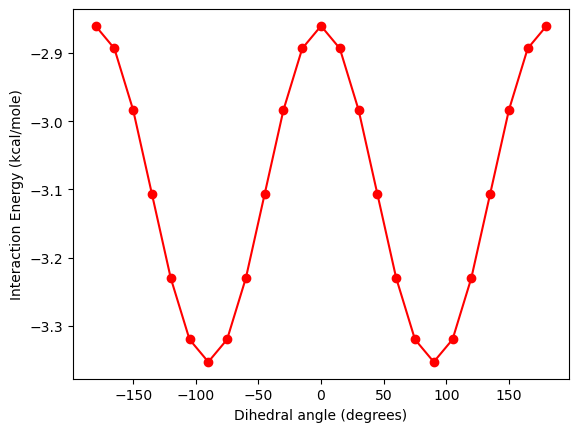

In [20]:
plt.figure()
plt.plot(Avals, energies_R, 'r-o')
plt.xlabel('Dihedral angle (degrees)')
plt.ylabel('Interaction Energy (kcal/mole)')

## 3D Plots

from
https://education.molssi.org/qm-tools/03-inter-pes/index.html

In [21]:
Rvals = np.linspace(start=1.8,stop=2.5,num=8)
Avals = np.linspace(start=-180,stop=180, num=25)

energy_2D = []

for R in Rvals:
    energies_R = []

    for A in Avals:

        print(F'Computing dimer at {R:.1f} angstroms and {A:.2f} degrees')

        # Build a new molecule at each separation
        B = A-180
        molR = water_dimer2.replace('**R**', str(R))
        molA = molR.replace('**A**', str(A))
        molB = molA.replace('**B**', str(B))
        mol = psi4.geometry(molB)

        # calculate energy
        psi4.set_output_file(F'{molecule_name}/{molecule_name}_{R:.1f}_{A:.2f}_energy.dat', False)
        E = psi4.energy('scf/aug-cc-pVDZ', molecule=mol, bsse_type='cp')       
        E = E*627.509
        energies_R.append(E)

    energy_2D.append(energies_R)

print(F'All calculations are complete!')

Computing dimer at 1.8 angstroms and -180.00 degrees
Computing dimer at 1.8 angstroms and -165.00 degrees
Computing dimer at 1.8 angstroms and -150.00 degrees
Computing dimer at 1.8 angstroms and -135.00 degrees
Computing dimer at 1.8 angstroms and -120.00 degrees
Computing dimer at 1.8 angstroms and -105.00 degrees
Computing dimer at 1.8 angstroms and -90.00 degrees
Computing dimer at 1.8 angstroms and -75.00 degrees
Computing dimer at 1.8 angstroms and -60.00 degrees
Computing dimer at 1.8 angstroms and -45.00 degrees
Computing dimer at 1.8 angstroms and -30.00 degrees
Computing dimer at 1.8 angstroms and -15.00 degrees
Computing dimer at 1.8 angstroms and 0.00 degrees
Computing dimer at 1.8 angstroms and 15.00 degrees
Computing dimer at 1.8 angstroms and 30.00 degrees
Computing dimer at 1.8 angstroms and 45.00 degrees
Computing dimer at 1.8 angstroms and 60.00 degrees
Computing dimer at 1.8 angstroms and 75.00 degrees
Computing dimer at 1.8 angstroms and 90.00 degrees
Computing dime

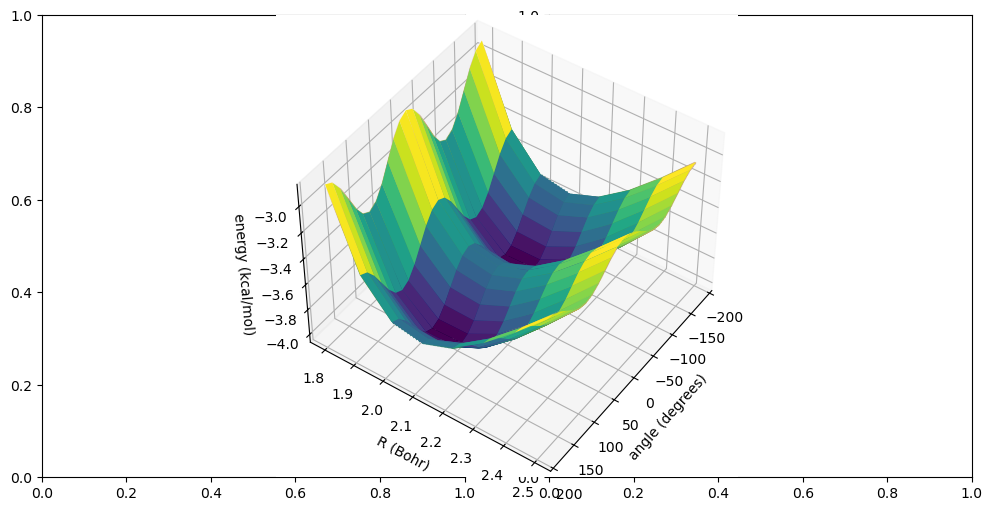

In [23]:
from mpl_toolkits import mplot3d
%matplotlib inline

X, Y = np.meshgrid(Avals, Rvals)

mycmap1 = plt.get_cmap('gist_earth')

fig, (ax,ax2) = plt.subplots(1,2,figsize=(12,6))

ax = plt.axes(projection='3d')
cf = ax.contour3D(X, Y, np.array(energy_2D), 300, cmap=mycmap1)
ax.plot_surface(X, Y, np.array(energy_2D), rstride=1, cstride=1, cmap='viridis', edgecolor='none')

ax.set_xlabel('angle (degrees)')
ax.set_ylabel('R (Bohr)')
ax.set_zlabel('energy (kcal/mol)')
#ax.set_zlim3d(-4,-2)
ax.view_init(45, 35)